In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2, InceptionV3, EfficientNetB0
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
TRAIN_PATH = r"C:\Users\Varshini V\OneDrive\Documents\VS_code\venv\Fish_image_classifcation\Dataset\images.cv_jzk6llhf18tm3k0kyttxz\data\train"
VAL_PATH = r"C:\Users\Varshini V\OneDrive\Documents\VS_code\venv\Fish_image_classifcation\Dataset\images.cv_jzk6llhf18tm3k0kyttxz\data\val"
IMG_SIZE = (224,224)
BATCH_SIZE = 32


train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        zoom_range=0.2,
        horizontal_flip=True,
        validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
        TRAIN_PATH,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='training'
)

val_generator = train_datagen.flow_from_directory(
        VAL_PATH,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='validation'
)

NUM_CLASSES = train_generator.num_classes
class_names = list(val_generator.class_indices.keys())
print("Classes:", train_generator.class_indices)
print("Class Names:", class_names)

Found 4984 images belonging to 11 classes.
Found 215 images belonging to 11 classes.
Classes: {'animal fish': 0, 'animal fish bass': 1, 'fish sea_food black_sea_sprat': 2, 'fish sea_food gilt_head_bream': 3, 'fish sea_food hourse_mackerel': 4, 'fish sea_food red_mullet': 5, 'fish sea_food red_sea_bream': 6, 'fish sea_food sea_bass': 7, 'fish sea_food shrimp': 8, 'fish sea_food striped_red_mullet': 9, 'fish sea_food trout': 10}
Class Names: ['animal fish', 'animal fish bass', 'fish sea_food black_sea_sprat', 'fish sea_food gilt_head_bream', 'fish sea_food hourse_mackerel', 'fish sea_food red_mullet', 'fish sea_food red_sea_bream', 'fish sea_food sea_bass', 'fish sea_food shrimp', 'fish sea_food striped_red_mullet', 'fish sea_food trout']


In [3]:
def build_cnn(input_shape, num_classes):

    model = Sequential([
        Conv2D(32,(3,3),activation='relu',input_shape=input_shape),
        MaxPooling2D(2,2),

        Conv2D(64,(3,3),activation='relu'),
        MaxPooling2D(2,2),

        Conv2D(128,(3,3),activation='relu'),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(256,activation='relu'),
        Dropout(0.5),
        Dense(num_classes,activation='softmax')
    ])

    return model

In [4]:
def build_transfer_model(base_model, num_classes):

    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)

    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    return model

In [5]:
def train_model(model, name):

    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=15
    )

    return history


In [7]:
cnn_model = build_cnn((224,224,3), NUM_CLASSES)
cnn_history = train_model(cnn_model, "cnn_model")

c:\Users\Varshini V\OneDrive\Documents\VS_code\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 66s 414ms/step - accuracy: 0.3732 - loss: 1.8047 - val_accuracy: 0.6233 - val_loss: 1.2507
Epoch 2/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 162s 1s/step - accuracy: 0.5630 - loss: 1.2735 - val_accuracy: 0.7349 - val_loss: 0.9315
Epoch 3/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 86s 554ms/step - accuracy: 0.6493 - loss: 1.0366 - val_accuracy: 0.6884 - val_loss: 0.8290
Epoch 4/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 54s 344ms/step - accuracy: 0.7059 - loss: 0.8781 - val_accuracy: 0.8047 - val_loss: 0.6402
Epoch 5/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 54s 344ms/step - accuracy: 0.7550 - loss: 0.7274 - val_accuracy: 0.8698 - val_loss: 0.5186
Epoch 6/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 53s 340ms/step - accuracy: 0.7873 - loss: 0.6391 - val_accuracy: 0.8744 - val_loss: 0.4789
Epoch 7/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 53s 341ms/step - accuracy: 0.8110 - loss: 0.5672 - val_accuracy: 0.9070 - val_loss: 0.4099
Epoch 8/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 54s 348ms/step - accuracy: 0.8246 - loss: 0.5

In [8]:
INPUT_SHAPE = (224, 224, 3)

models_dict = {
    "VGG16": VGG16(weights="imagenet", include_top=False, input_shape=INPUT_SHAPE),
    "ResNet50": ResNet50(weights="imagenet", include_top=False, input_shape=INPUT_SHAPE),
    "MobileNetV2": MobileNetV2(weights="imagenet", include_top=False, input_shape=INPUT_SHAPE),
    "InceptionV3": InceptionV3(weights="imagenet", include_top=False, input_shape=INPUT_SHAPE),
    "EfficientNetB0": EfficientNetB0(weights="imagenet", include_top=False, input_shape=INPUT_SHAPE)
}

histories = {}

for model_name, base_model in models_dict.items():

    print(f"Training Model: {model_name}")

    model = build_transfer_model(base_model, NUM_CLASSES)

    history = train_model(model, model_name)
    histories[model_name] = history

print("\nAll models trained successfully.")

Training Model: VGG16
Epoch 1/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 226s 1s/step - accuracy: 0.2016 - loss: 2.2876 - val_accuracy: 0.3256 - val_loss: 2.0449
Epoch 2/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 231s 1s/step - accuracy: 0.3134 - loss: 1.9871 - val_accuracy: 0.5302 - val_loss: 1.8608
Epoch 3/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 228s 1s/step - accuracy: 0.4017 - loss: 1.8047 - val_accuracy: 0.6419 - val_loss: 1.7180
Epoch 4/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 458s 3s/step - accuracy: 0.4908 - loss: 1.6525 - val_accuracy: 0.6372 - val_loss: 1.5955
Epoch 5/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 267s 2s/step - accuracy: 0.5576 - loss: 1.5309 - val_accuracy: 0.6977 - val_loss: 1.4816
Epoch 6/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 280s 2s/step - accuracy: 0.5881 - loss: 1.4379 - val_accuracy: 0.6791 - val_loss: 1.3840
Epoch 7/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 240s 2s/step - accuracy: 0.6280 - loss: 1.3420 - val_accuracy: 0.7116 - val_loss: 1.3006
Epoch 8/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/step - accuracy: 0.6629 - l

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 427ms/step
              precision    recall  f1-score   support

           0       0.10      0.11      0.11        37
           1       0.00      0.00      0.00         2
           2       0.05      0.05      0.05        21
           3       0.06      0.06      0.06        18
           4       0.09      0.11      0.10        19
           5       0.06      0.06      0.06        18
           6       0.09      0.09      0.09        22
           7       0.31      0.26      0.29        19
           8       0.25      0.25      0.25        20
           9       0.18      0.20      0.19        20
          10       0.00      0.00      0.00        19

    accuracy                           0.12       215
   macro avg       0.11      0.11      0.11       215
weighted avg       0.12      0.12      0.12       215



c:\Users\Varshini V\OneDrive\Documents\VS_code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Varshini V\OneDrive\Documents\VS_code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Varshini V\OneDrive\Documents\VS_code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

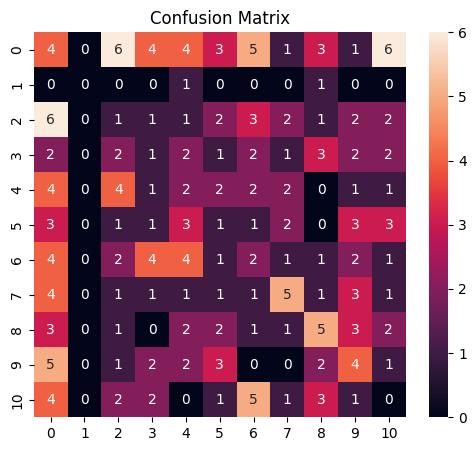

In [9]:
def evaluate_model(model):

    val_generator.reset()

    preds = model.predict(val_generator)
    y_pred = np.argmax(preds, axis=1)

    y_true = val_generator.classes

    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true,y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title("Confusion Matrix")
    plt.show()

evaluate_model(cnn_model)

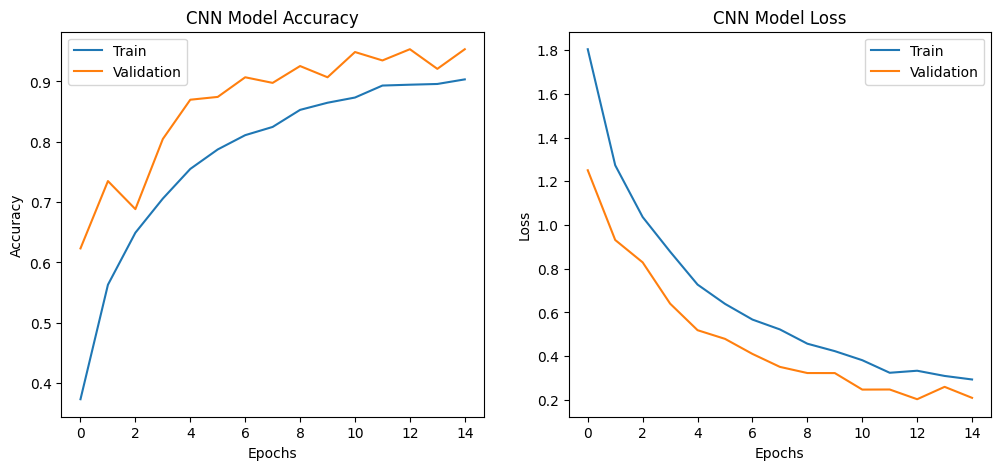

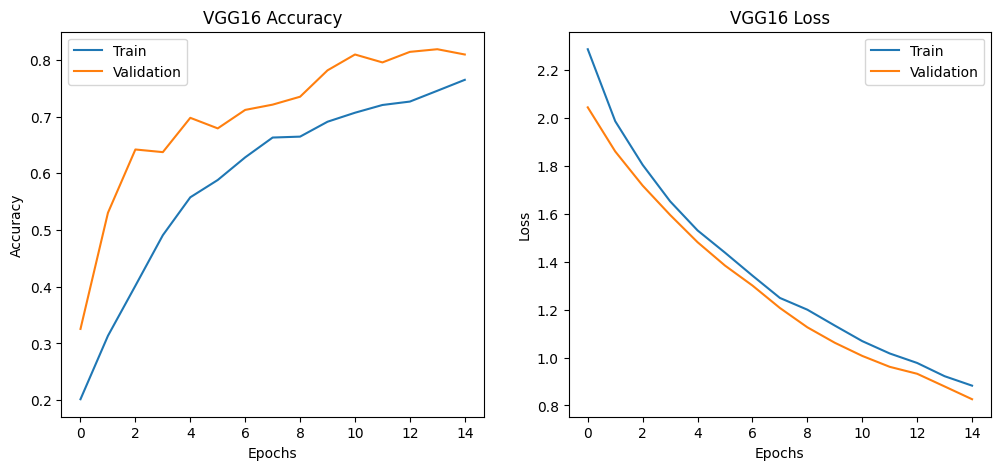

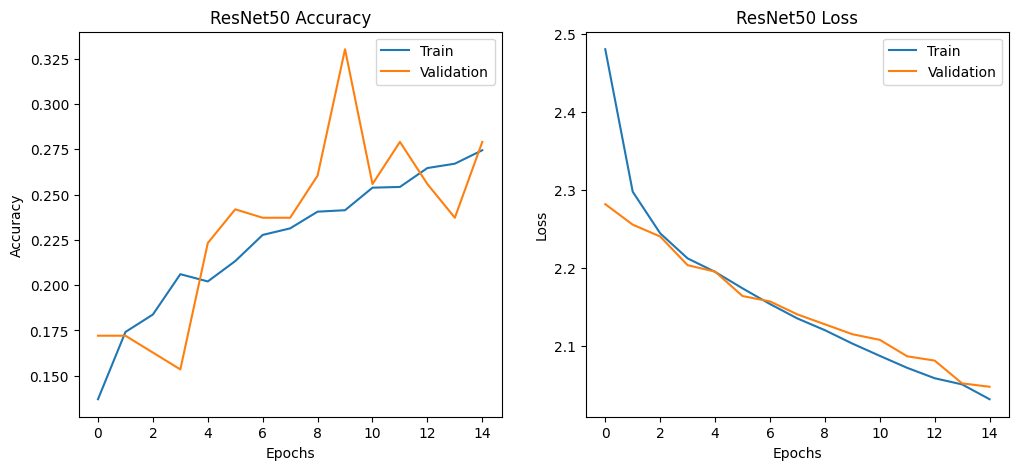

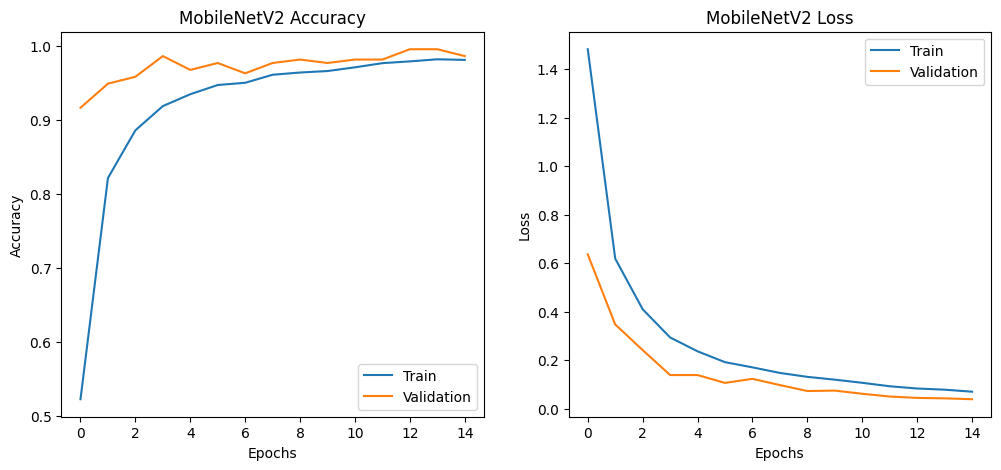

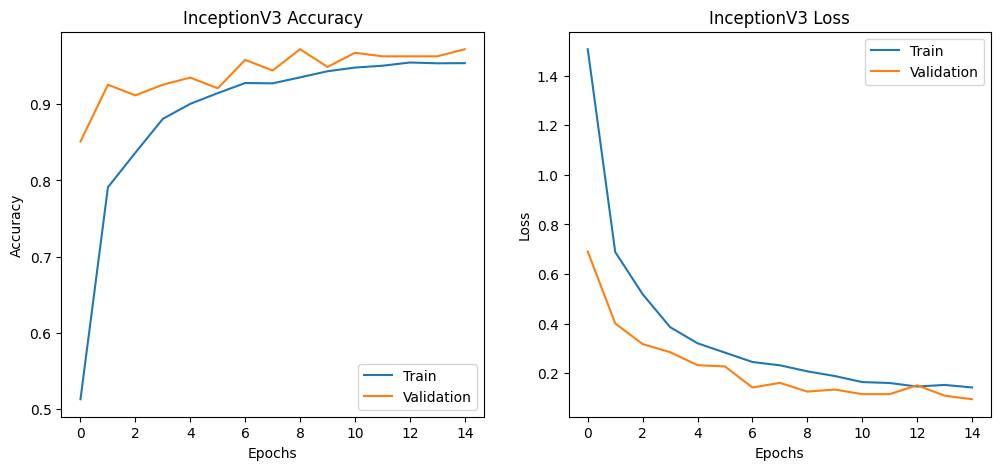

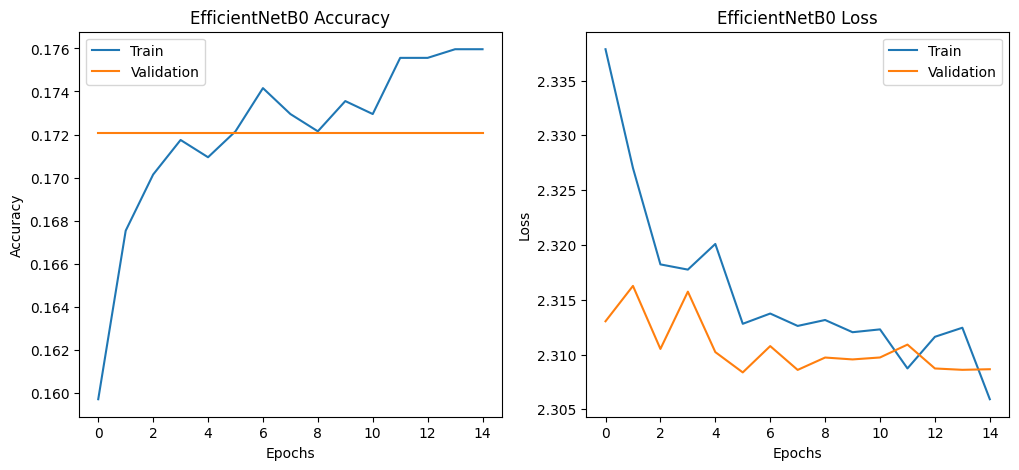

In [10]:
def plot_history(history, title):

    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(title + " Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend(['Train','Validation'])

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(title + " Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend(['Train','Validation'])

    plt.show()

plot_history(cnn_history, "CNN Model")
plot_history(histories["VGG16"], "VGG16")
plot_history(histories["ResNet50"], "ResNet50")
plot_history(histories["MobileNetV2"], "MobileNetV2")
plot_history(histories["InceptionV3"], "InceptionV3")
plot_history(histories["EfficientNetB0"], "EfficientNetB0")

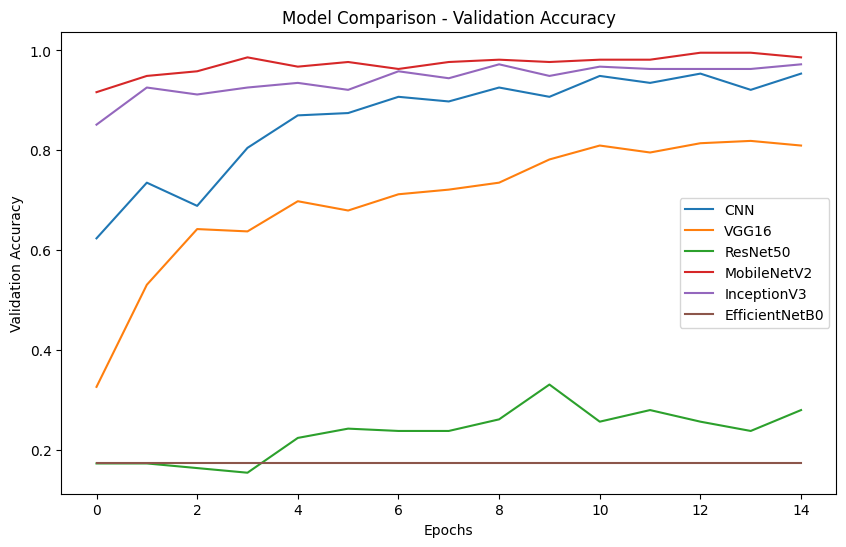

In [11]:
def compare_models(histories, cnn_history):

    plt.figure(figsize=(10,6))

    # CNN
    plt.plot(cnn_history.history['val_accuracy'], label='CNN')

    # Transfer learning models
    for model_name, history in histories.items():
        plt.plot(history.history['val_accuracy'], label=model_name)

    plt.title("Model Comparison - Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Validation Accuracy")
    plt.legend()
    plt.show()

compare_models(histories, cnn_history)

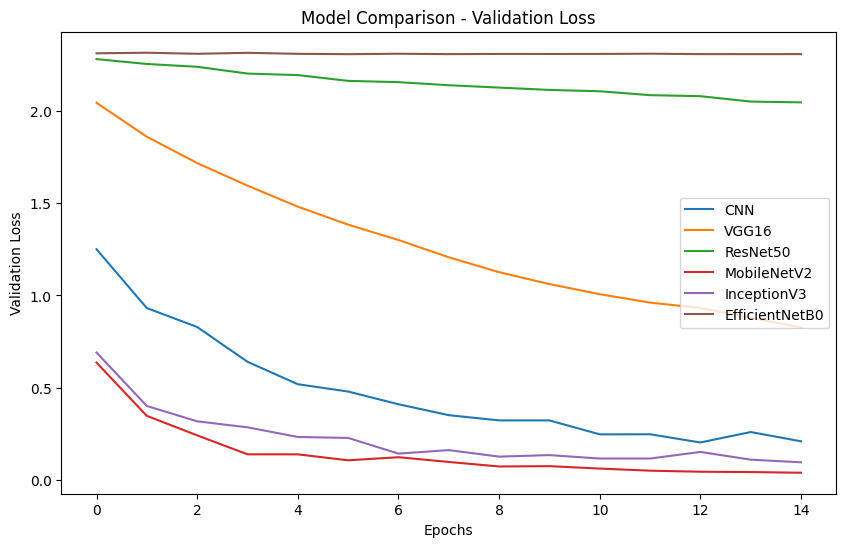

In [12]:
def compare_loss(histories, cnn_history):

    plt.figure(figsize=(10,6))

    plt.plot(cnn_history.history['val_loss'], label='CNN')

    for model_name, history in histories.items():
        plt.plot(history.history['val_loss'], label=model_name)

    plt.title("Model Comparison - Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Validation Loss")
    plt.legend()
    plt.show()

compare_loss(histories, cnn_history)

In [13]:
cnn_model.save("models/fish_classifier.h5")

print("Model saved successfully.")


Model saved successfully.
